<a href="https://colab.research.google.com/github/actualabhishek/LLM_Engineering_Journey/blob/master/Fine_tuning/Fine_tunning_gemma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q -U transformers "datasets>=4.7.0" peft trl bitsandbytes accelerate pyarrow fsspec gcsfs scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 107.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.8/775.8 kB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 889.0/889.0 kB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.9/203.9 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 125.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.2/102.2 kB 8.7 MB/s eta 0:00:00


In [2]:
import torch
if torch.cuda.is_available():
  print(f"GPU is vailable :{torch.cuda.get_device_name(0)}")
else:
  print("GPU is not available")

GPU is vailable :Tesla T4


In [3]:
LLM_model = "google/gemma-3-1b-it"
dataset_id = "Daniel-ML/sentiment-analysis-for-financial-news-v2"

In [4]:
from huggingface_hub import login
from google.colab import userdata
print("Attempting Huggingface login")
hf_token = userdata.get("HF_TOKEN")
login(token=hf_token)
print("Huggingface login successful!")

Attempting Huggingface login
Huggingface login successful!


In [5]:
from datasets import load_dataset
labled_dataset = load_dataset(dataset_id, split="train")


README.md:   0%|          | 0.00/36.0 [00:00<?, ?B/s]

pd_df_json.json:   0%|          | 0.00/788k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4846 [00:00<?, ? examples/s]

In [7]:
print(labled_dataset)

Dataset({
    features: ['sentiment', 'text'],
    num_rows: 4846
})


In [8]:
print(labled_dataset.features)

{'sentiment': Value('string'), 'text': Value('string')}


In [9]:
import pandas as pd
unique_lable = labled_dataset.to_pandas()['sentiment'].unique().tolist()
print(f"unique labels in dataset is {unique_lable}")
pd.DataFrame(unique_lable)


unique labels in dataset is ['neutral', 'negative', 'positive']


,0
0,neutral
1,negative
2,positive


In [11]:
# Let's Split the Data into Train and Test Sets ---
test_size_ratio = 0.10
seed =42
split_dataset = labled_dataset.train_test_split(
    test_size=test_size_ratio,
    seed= seed,
    shuffle=True,
)
print(split_dataset)
training_dataset = split_dataset['train']
test_dataset = split_dataset['test']
print(f"Train dataset size is {len(split_dataset['train'])}")
print(f"Test dataset size is {len(split_dataset['test'])}")

DatasetDict({
    train: Dataset({
        features: ['sentiment', 'text'],
        num_rows: 4361
    })
    test: Dataset({
        features: ['sentiment', 'text'],
        num_rows: 485
    })
})
Train dataset size is 4361
Test dataset size is 485


<Axes: xlabel='count'>

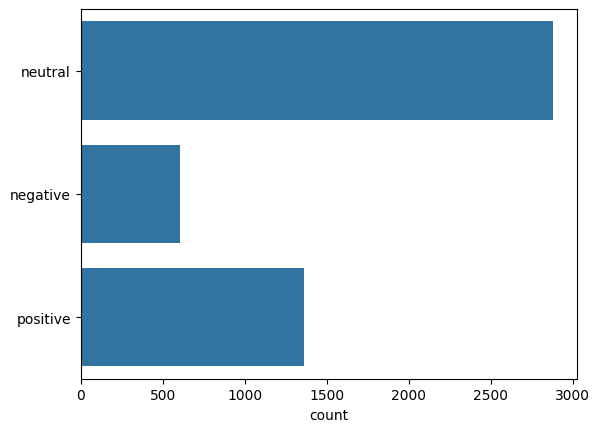

In [12]:
import seaborn as sns
sns.countplot(labled_dataset['sentiment'])

In [13]:
def sft_gemma(example, tokenizer):
  system_prompt = "Classify the sentiment of the following sentence from News as positive, negative, or neutral."


  user_prompt = f'Sentence : {example["text"]}'
  assistant_response = example["sentiment"]

  message = [{"role": "user", "content":f'{system_prompt}\n{user_prompt}'},
             {"role" : "assistant", "content": assistant_response}]

  input = tokenizer.apply_chat_template(
      message,
      tokenize = False,
      add_generation_prompt = False,
  )

  return {"text": input}




In [14]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

In [16]:
example_text = {
  "text": "The economy is showing signs of recovery after a tough year.",
  "sentiment": "positive"
  }
quant_config = BitsAndBytesConfig(
    load_in_4bit = True,
    bnb_4bit_compute_dtype = torch.float16,
    bnb_4bit_quant_type = "nf4",
    bnb_4bit_use_double_quant = True,
)
tokenizer = AutoTokenizer.from_pretrained(LLM_model)

if tokenizer.pad_token is None:
 tokenizer.pad_token = tokenizer.eos_token


formatted_example = sft_gemma(example_text, tokenizer)

formatted_example

{'text': '<bos><start_of_turn>user\nClassify the sentiment of the following sentence from News as positive, negative, or neutral.\nSentence : The economy is showing signs of recovery after a tough year.<end_of_turn>\n<start_of_turn>model\npositive<end_of_turn>\n'}

In [17]:
model = AutoModelForCausalLM.from_pretrained(
    LLM_model,
    quantization_config = quant_config,
    device_map = "auto",
    trust_remote_code = True,
)
model.config.pad_token_id = tokenizer.pad_token_id

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.00GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

In [18]:
model

Gemma3ForCausalLM(
  (model): Gemma3TextModel(
    (embed_tokens): Gemma3TextScaledWordEmbedding(262144, 1152, padding_idx=0)
    (layers): ModuleList(
      (0-25): 26 x Gemma3DecoderLayer(
        (self_attn): Gemma3Attention(
          (q_proj): Linear4bit(in_features=1152, out_features=1024, bias=False)
          (k_proj): Linear4bit(in_features=1152, out_features=256, bias=False)
          (v_proj): Linear4bit(in_features=1152, out_features=256, bias=False)
          (o_proj): Linear4bit(in_features=1024, out_features=1152, bias=False)
          (q_norm): Gemma3RMSNorm((256,), eps=1e-06)
          (k_norm): Gemma3RMSNorm((256,), eps=1e-06)
        )
        (mlp): Gemma3MLP(
          (gate_proj): Linear4bit(in_features=1152, out_features=6912, bias=False)
          (up_proj): Linear4bit(in_features=1152, out_features=6912, bias=False)
          (down_proj): Linear4bit(in_features=6912, out_features=1152, bias=False)
          (act_fn): GELUTanh()
        )
        (input_layernor

In [20]:
sft_train_dataset = training_dataset.map(sft_gemma, fn_kwargs={"tokenizer": tokenizer}, remove_columns=training_dataset.features)
sft_test_dataset = test_dataset.map(sft_gemma, fn_kwargs={"tokenizer": tokenizer}, remove_columns=test_dataset.features)

print(sft_train_dataset[0])
print(sft_test_dataset[15])

{'text': '<bos><start_of_turn>user\nClassify the sentiment of the following sentence from News as positive, negative, or neutral.\nSentence : These module products will be available for trials during 3Q-07 and for volume deliveries during 4Q-07 .<end_of_turn>\n<start_of_turn>model\nneutral<end_of_turn>\n'}
{'text': '<bos><start_of_turn>user\nClassify the sentiment of the following sentence from News as positive, negative, or neutral.\nSentence : The exercise originated in Finland in the early 1930s as a training method for cross-country skiers .<end_of_turn>\n<start_of_turn>model\nneutral<end_of_turn>\n'}


In [23]:
# Perform Zero-Shot Classification Prompt Function (Gemma)
def create_zero_shot_prompt(sentence, tokenizer):
  system_prompt = f"Classify the sentiment of the following sentence from News as positive, negative, or neutral. RETURN ONLY ONE WORD {', '.join(unique_lable)}"

  user_prompt = f'Sentence : {sentence}'

  message = [{"role": "user", "content":f'{system_prompt}\n{user_prompt}'}],
  input = tokenizer.apply_chat_template(
      message,
      tokenize = False,
      add_generation_prompt = True,
  )

  return input

In [28]:
def inference_zero_shot(model, tokenizer, sentence):
  prompt = create_zero_shot_prompt(sentence, tokenizer)
  input = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=500).to(model.device)
  eos_id = tokenizer.eos_token_id
  pad_id = tokenizer.pad_token_id
  with torch.no_grad():
    output = model.generate(
        **input,
        max_new_tokens=10,
        eos_token_id=eos_id,
        pad_token_id=pad_id,
        do_sample = False
    )

    response_id = output[0][input["input_ids"].shape[1]:]
    response_text = tokenizer.decode(response_id, skip_special_tokens=True).strip()

    labels = ["neutral", "negative", "positive"]

    predicted_label = "Unknown"
    for label_text in labels:
        if label_text.lower() in response_text.lower(): # Simple check if label is present
              predicted_label = label_text
              break

    print(f"Predicted Label: {predicted_label}")
    return predicted_label

In [29]:
true_labels = []

# Let's extract the ground truth (target output) which represents the True class
true_labels = [ex['sentiment'] for ex in test_dataset]
true_labels

['neutral',
 'negative',
 'neutral',
 'positive',
 'neutral',
 'neutral',
 'neutral',
 'positive',
 'neutral',
 'neutral',
 'positive',
 'positive',
 'negative',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'positive',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'positive',
 'neutral',
 'positive',
 'neutral',
 'positive',
 'neutral',
 'negative',
 'negative',
 'positive',
 'neutral',
 'neutral',
 'neutral',
 'positive',
 'neutral',
 'positive',
 'negative',
 'neutral',
 'positive',
 'positive',
 'positive',
 'neutral',
 'positive',
 'positive',
 'neutral',
 'neutral',
 'neutral',
 'neutral',
 'positive',
 'negative',
 'neutral',
 'positive',
 'negative',
 'neutral',
 'neutral',
 'positive',
 'neutral',
 'neutral',
 'positive',
 'neutral',
 'positive',
 'neutral',
 'neutral',
 'neutral',
 'negative',
 'positive',
 'positive',
 'positive',
 'negative',
 'positive',
 'positive',
 'neutral',
 'neutral',
 'positive',
 'neutral',
 'neutral',
 'neutral',
 'negative',
 'positive',
 '

In [31]:
from tqdm.notebook import tqdm
base_os_predictions = []
for example in tqdm(test_dataset):
    predicted_label = inference_zero_shot(model, tokenizer, example['text'])
    base_os_predictions.append(predicted_label)

  0%|          | 0/485 [00:00<?, ?it/s]

Predicted Label: positive
Predicted Label: negative
Predicted Label: negative
Predicted Label: positive
Predicted Label: positive
Predicted Label: positive
Predicted Label: neutral
Predicted Label: positive
Predicted Label: positive
Predicted Label: neutral
Predicted Label: positive
Predicted Label: positive
Predicted Label: neutral
Predicted Label: positive
Predicted Label: positive
Predicted Label: positive
Predicted Label: negative
Predicted Label: positive
Predicted Label: positive
Predicted Label: positive
Predicted Label: neutral
Predicted Label: positive
Predicted Label: positive
Predicted Label: negative
Predicted Label: positive
Predicted Label: negative
Predicted Label: positive
Predicted Label: positive
Predicted Label: negative
Predicted Label: negative
Predicted Label: positive
Predicted Label: neutral
Predicted Label: positive
Predicted Label: positive
Predicted Label: positive
Predicted Label: positive
Predicted Label: positive
Predicted Label: negative
Predicted Label: 

In [35]:
from sklearn.metrics import classification_report, accuracy_score


valid_indices = [i for i, p in enumerate(base_os_predictions) if p not in ["Error", "Unknown"]]
filtered_pred = [base_os_predictions [i] for i in valid_indices]
filtered_true = [true_labels[i] for i in valid_indices]

accuracy = accuracy_score(filtered_true, filtered_pred)
report = classification_report(filtered_true, filtered_pred)

print(f"Accuracy: {accuracy}")
print("\nClassification Report:")
print(report)
print(f"Accuracy: {accuracy}")
print("\nClassification Report:")
print(report)

Accuracy: 0.5010309278350515

Classification Report:
              precision    recall  f1-score   support

    negative       0.49      0.84      0.62        56
     neutral       0.88      0.24      0.38       290
    positive       0.41      0.91      0.56       139

    accuracy                           0.50       485
   macro avg       0.59      0.66      0.52       485
weighted avg       0.70      0.50      0.46       485

Accuracy: 0.5010309278350515

Classification Report:
              precision    recall  f1-score   support

    negative       0.49      0.84      0.62        56
     neutral       0.88      0.24      0.38       290
    positive       0.41      0.91      0.56       139

    accuracy                           0.50       485
   macro avg       0.59      0.66      0.52       485
weighted avg       0.70      0.50      0.46       485



In [40]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer, SFTConfig

model.gradient_checkpointing_enable()
prepared_model = prepare_model_for_kbit_training(model)
lora_config = LoraConfig(
    r = 16,
    lora_alpha = 32,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout = 0.05,
    bias = "none",
    task_type = "CAUSAL_LM"
)

peft_model = get_peft_model(prepared_model, lora_config)

print("PEFT model created.")
peft_model.print_trainable_parameters()

/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:305: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


PEFT model created.
trainable params: 2,981,888 || all params: 1,002,867,840 || trainable%: 0.2973


In [46]:
from transformers import TrainingArguments
import torch
output_dir = "./sentiment_finetuned_adapter"  # Directory to save adapter weights

training_args = TrainingArguments(
    output_dir = output_dir,
    per_device_train_batch_size = 4,  # Adjust based on GPU memory (2, 4, 8 typical for Colab)
    gradient_accumulation_steps = 2,  # Effective batch size = batch_size * grad_accum_steps
    learning_rate = 2e-4,  # Common starting point for LoRA
    num_train_epochs = 1,  # Start with 1 epoch for faster iteration/testing. Increase to 2-3 if needed.
    logging_steps = 25,  # Log training loss every N steps
    save_strategy = "epoch",  # Save adapter checkpoint at the end of each epoch
    # optim="paged_adamw_8bit", # Use paged optimizer for memory efficiency (requires bitsandbytes >= 0.41.0) - try if memory issues occur
    fp16=not torch.cuda.is_bf16_supported(),  # Use fp16 if bf16 not supported
    bf16 = torch.cuda.is_bf16_supported(),  # Use bf16 if supported (preferred)
    max_grad_norm = 0.3,  # Gradient clipping
    warmup_ratio = 0.03,  # Learning rate warmup
    lr_scheduler_type = "constant",  # Or "linear", "cosine"
    report_to = "none",  # Disable wandb/tensorboard reporting for simplicity
)
print("Training Arguments set.")

# --- Initialize SFTTrainer ---
trainer = SFTTrainer(
    model=model,       # plain base model, NOT peft_model
    args=training_args,
    train_dataset=sft_train_dataset,
    processing_class=tokenizer,
    peft_config=lora_config,   # trainer wraps it internally

)
print("SFTTrainer initialized.")

# --- Start Fine-tuning ---
print("\n--- Starting Fine-tuning... ---")
try:
    training_results = trainer.train()
    print("--- Fine-tuning Complete! ---")
    print(training_results)

    # --- Save the LoRA Adapter ---
    print(f"Saving LoRA adapter model to {output_dir}...")
    trainer.save_model(output_dir)  # Saves only the adapter weights
    # Also save the tokenizer for consistency
    tokenizer.save_pretrained(output_dir)
    print("Adapter and tokenizer saved.")

    # --- Clean up memory (important before loading for evaluation) ---
    del trainer
    del peft_model  # Delete the model used for training
    # del prepared_model # Optional
    # del base_os_model # Keep the original base model if needed later, or delete
    torch.cuda.empty_cache()
    import gc

    gc.collect()
    print("Cleaned up training objects from memory.")

    fine_tuning_successful = True

except Exception as e:
    print(f"Error during fine-tuning: {e}")


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:305: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Training Arguments set.


Adding EOS to train dataset:   0%|          | 0/4361 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/4361 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/4361 [00:00<?, ? examples/s]

...

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1}.


SFTTrainer initialized.

--- Starting Fine-tuning... ---


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
25,3.640487
50,2.042348
75,1.774701
100,1.634546
125,1.644490
150,1.576742
175,1.562452
200,1.545418
225,1.555835
250,1.540472


--- Fine-tuning Complete! ---
TrainOutput(global_step=546, training_loss=1.6715544431637495, metrics={'train_runtime': 1393.084, 'train_samples_per_second': 3.13, 'train_steps_per_second': 0.392, 'total_flos': 1502685132599808.0, 'train_loss': 1.6715544431637495, 'entropy': 1.4813191047528895, 'num_tokens': 285498.0, 'mean_token_accuracy': 0.7060281997773705, 'epoch': 1.0})
Saving LoRA adapter model to ./sentiment_finetuned_adapter...
Adapter and tokenizer saved.
Cleaned up training objects from memory.
